# Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect
import seaborn as sns
import re
import nltk
#nltk.download('stopwords')
nltk.download('punkt_tab')  # Also download 'punkt' for tokenization if not already done

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from palettable.colorbrewer.diverging import RdBu_8
import stylecloud
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
from sklearn.decomposition import PCA

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#!pip install -U sentence-transformers

# Load Dataset

In [4]:
coursera_df = pd.read_csv('coursera_courses.csv')
people_df = pd.read_csv('./people.csv')

In [5]:
coursera_df.head()

,course_title,course_organization,course_certificate_type,course_time,course_rating,course_reviews_num,course_difficulty,course_url,course_students_enrolled,course_skills,course_summary,course_description
0,(ISC)² Systems Security Certified Practitioner...,ISC2,Specialization,3 - 6 Months,4.7,492,Beginner,https://www.coursera.org/specializations/sscp-...,"6,958","['Risk Management', 'Access Control', 'Asset',...",[],Pursue better IT security job opportunities an...
1,.NET FullStack Developer,Board Infinity,Specialization,1 - 3 Months,4.3,51,Intermediate,https://www.coursera.org/specializations/dot-n...,"2,531","['Web API', 'Web Development', 'Cascading Styl...",['Master .NET full stack web dev: from .NET co...,Develop the proficiency required to design and...
2,21st Century Energy Transition: how do we make...,University of Alberta,Course,1 - 3 Months,4.8,62,Beginner,https://www.coursera.org/learn/21st-century-en...,"4,377",[],['Understand the complexity of systems supplyi...,"Affordable, abundant and reliable energy is fu..."
3,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,Course,1 - 3 Months,4.7,517,Intermediate,https://www.coursera.org/learn/crash-course-in...,"39,004","['Instrumental Variable', 'Propensity Score Ma...",[],We have all heard the phrase “correlation does...
4,A life with ADHD,University of Geneva,Course,1 - 3 Months,NaN,NaN,Beginner,https://www.coursera.org/learn/life-with-adhd,NaN,"['differential diagnosis and comorbidities', '...",[' Understand what ADHD is and the challenges ...,What is ADHD and what are the challenges that ...


In [6]:
people_df.head()

,Unnamed: 0,name,about,position,experience,education,courses,projects,experience_titles,recent_ed,experience_descriptions,course_titles,project_titles,project_desription
0,0,Sai S****s ***,Welcome to my LinkedIn profile! I am a motivat...,Associate Product Manager II @ShopDeck | Axxel...,"[{""company"":""ShopDeck"",""company_id"":""shopdeck""...","[{""degree"":""B.Tech"",""description"":""Activities ...",NaN,NaN,"Associate Product Manager II, Trainee Analyst,...",Mechanical Engineering,", » Executed numerous daily trading strategies...",NaN,NaN,NaN
1,1,Lauren D****n,I lead inclusive programs to grow and develop ...,NaN,NaN,"[{""description"":null,""description_html"":null,""...","[{""subtitle"":""-"",""title"":""Applied Entrepreneur...","[{""description"":""Design and maintain website f...",NaN,NaN,NaN,"Applied Entrepreneurship, Cost Control & Finan...",Promotion of Gateway Convention Center and Hot...,Design and maintain website for Gateway Conven...
2,2,Nishita G***a,- Leading Claims Analytics Team at Munich Re S...,Head of Large Loss & Claims Analytics - Global...,"[{""company"":""Munich Re"",""company_id"":""munich-r...","[{""degree"":""Master of Science - MS"",""descripti...","[{""subtitle"":""-"",""title"":""Big Data Seminar""},{...",NaN,"Munich Re, MI Team Lead, Bristlecone",Business Intelligence and Analytics,", •\tLed MI & Analytics division by managing 4...","Big Data Seminar, Data Warehousing/Business In...",NaN,NaN
3,3,"John D******a M**, C***, C**, N**, R***, P**, **",Owner and President - AD Fiduciary - Fiduciary...,"Professional Fiduciary, Owner, President at AD...","[{""company"":""AD Fiduciary"",""company_logo_url"":...","[{""degree"":""MBA"",""description"":""Master of Busi...","[{""subtitle"":""-"",""title"":""RCFE Administrator C...",NaN,"AD Fiduciary, IKOR International, President",Strategic Planning,", , Owner operator of residential care for the...",RCFE Administrator Certification,NaN,NaN
4,4,Frederic L*****E,DIGITAL BUSINESS DESIGNER - I leverage digital...,NaN,NaN,"[{""description"":null,""description_html"":null,""...",NaN,"[{""description"":""A Trusted Platform for Wirele...",NaN,NaN,NaN,NaN,European Union - T2R (Trusted Transaction Roam...,A Trusted Platform for Wireless Data Services ...


# Coursera Dataset preprocessing

In [8]:
def data_preprocess(s_text):
    # Convert all text to lowercase
    if isinstance(s_text, str):
        s_text = s_text.lower()
    else:
        s_text = s_text.str.lower()

    # Remove digits and non-word characters (punctuation, symbols, etc.)
    s_text = s_text.apply(lambda text: re.sub(r'[\d\W]+', ' ', str(text)))

    # Tokenize the text (split into words)
    s_text = s_text.apply(lambda text: word_tokenize(text))

    # Define standard English stopwords and add custom stopwords
    stop_words = set(stopwords.words('english'))
    custom_stopwords = {"course", "learning", "youll", "use", "courses", "skills", "using", "also", "new"}
    stop_words.update(custom_stopwords)

    # Remove stopwords from the tokens
    s_text = s_text.apply(lambda tokens: [word for word in tokens if word not in stop_words])

    # Apply stemming to reduce words to their base/root form
    stemmer = PorterStemmer()
    s_text = s_text.apply(lambda tokens: [stemmer.stem(word) for word in tokens])

    # Join the list of stemmed tokens back into a single string
    s_text = s_text.apply(lambda tokens: ' '.join(tokens))

    return s_text

In [9]:
# Function to detect the language of a given text
def detect_language(text):
    try:
        return detect(text)  # Use langdetect's detect() method to identify language
    except:
        return None  # Return None if text is empty, invalid, or detection fails

# Apply language detection on key text fields in the dataset
# Detect language of the course title
coursera_df['lang_title'] = coursera_df['course_title'].apply(detect_language)

# Detect language of the course summary
coursera_df['lang_summary'] = coursera_df['course_summary'].apply(detect_language)

# Detect language of the course description
coursera_df['lang_description'] = coursera_df['course_description'].apply(detect_language)

In [10]:
coursera_df.drop(columns = ['course_students_enrolled', 'course_reviews_num'], inplace = True)

In [11]:
coursera_df.shape

(1000, 13)

In [12]:
coursera_df['course_id'] = coursera_df.index

In [13]:
# Removing Non-English courses
coursera_df = coursera_df[coursera_df['lang_title'] == 'en']

In [14]:
coursera_df.shape

(819, 14)

In [15]:
coursera_df[coursera_df['lang_summary'] == 'en'].count()

course_title               462
course_organization        462
course_certificate_type    462
course_time                462
course_rating              458
course_difficulty          462
course_url                 462
course_skills              462
course_summary             462
course_description         461
lang_title                 462
lang_summary               462
lang_description           461
course_id                  462
dtype: int64

In [16]:
coursera_df.drop(columns = ['course_summary'], inplace = True)

In [17]:
coursera_df[coursera_df['lang_description'] == 'en'].count()

course_title               796
course_organization        796
course_certificate_type    796
course_time                796
course_rating              791
course_difficulty          796
course_url                 796
course_skills              796
course_description         796
lang_title                 796
lang_summary               462
lang_description           796
course_id                  796
dtype: int64

In [18]:
coursera_df = coursera_df[coursera_df['lang_description'] == 'en']

In [19]:
coursera_df.shape

(796, 13)

In [20]:
coursera_df = coursera_df.drop(columns=['lang_title', 'lang_summary', 'lang_description'])

In [21]:
coursera_df['course_description'] = coursera_df['course_description'].replace('[]', np.nan)

In [22]:
coursera_df['course_description'].isna().sum()

0

# LinkedIn Profile Dataset Preprocessing

In [24]:
people_df = people_df.fillna('')

In [25]:
people_df['complete_profile'] = people_df[['about', 'experience_titles', 'experience_descriptions', 'recent_ed', 'course_titles', 'project_titles', 'project_desription']].apply(lambda row: ' '.join(row.astype(str)), axis=1)

In [26]:
people_df['processed_profile'] = data_preprocess(people_df['complete_profile'])

In [27]:
people_df['user_id'] = people_df.index

# Exploratory Data Analysis (EDA)

## Courses EDA

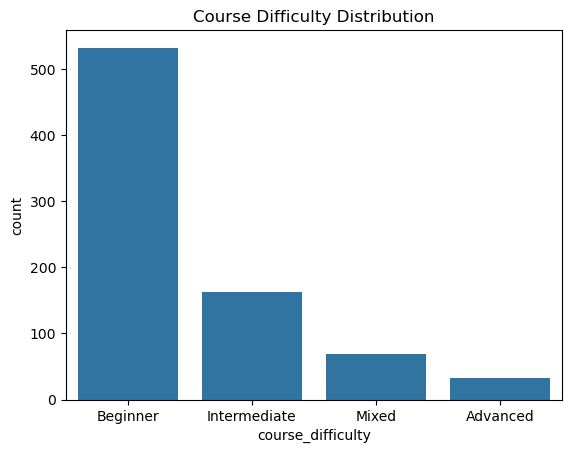

In [30]:
# Create a count plot to visualize the number of courses by difficulty level
sns.countplot(x=coursera_df['course_difficulty'])

# Set the title of the plot
plt.title("Course Difficulty Distribution")

# Display the plot
plt.show()

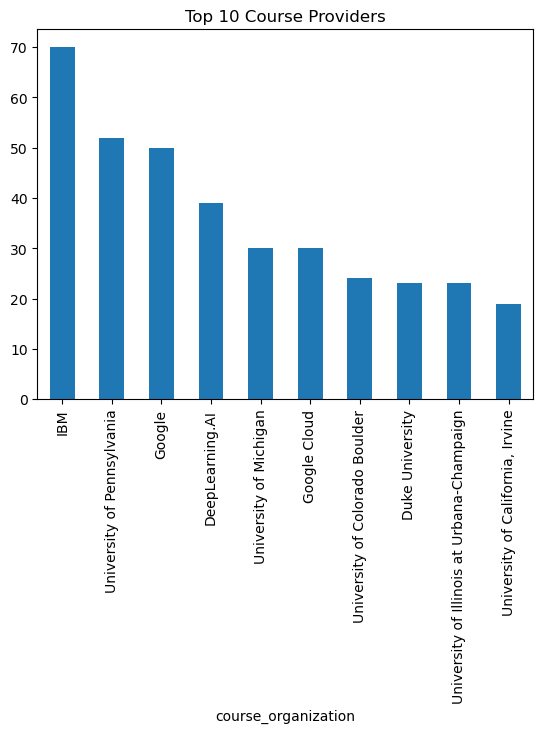

In [31]:
# Get the top 10 most frequent course providers and plot them as a bar chart
coursera_df['course_organization'].value_counts().head(10).plot(kind='bar')

# Set the title of the bar chart
plt.title("Top 10 Course Providers")

# Display the plot
plt.show()

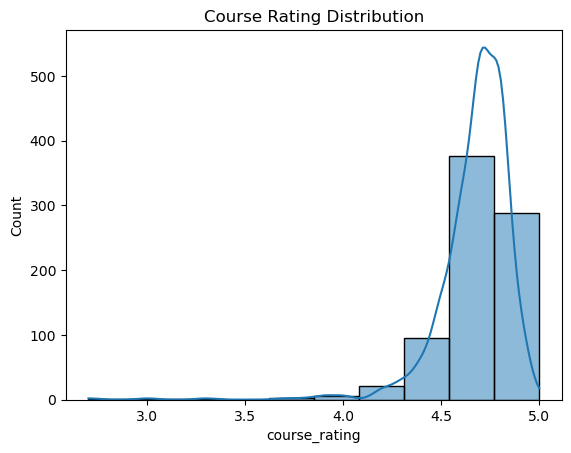

In [32]:
# Plot a histogram of course ratings with 10 bins and a kernel density estimate (KDE) line
sns.histplot(coursera_df['course_rating'], bins=10, kde=True)

# Set the title of the histogram
plt.title("Course Rating Distribution")

# Display the plot
plt.show()


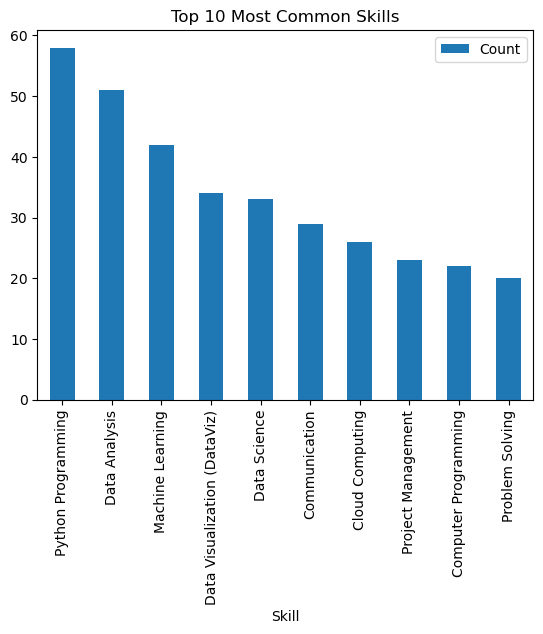

In [33]:
from collections import Counter
import itertools

# Flatten the list of skills from all courses into a single list
# - dropna() removes missing values
# - apply(eval) converts string representations of lists to actual lists
# - itertools.chain flattens the list of lists
all_skills = list(itertools.chain.from_iterable(coursera_df['course_skills'].dropna().apply(eval)))

# Count the frequency of each skill
skill_counts = Counter(all_skills)

# Create a DataFrame of the top 10 most common skills and plot them as a bar chart
pd.DataFrame(skill_counts.most_common(10), columns=['Skill', 'Count']) \
    .set_index('Skill') \
    .plot(kind='bar')

# Set the title of the bar chart
plt.title("Top 10 Most Common Skills")

# Display the plot
plt.show()

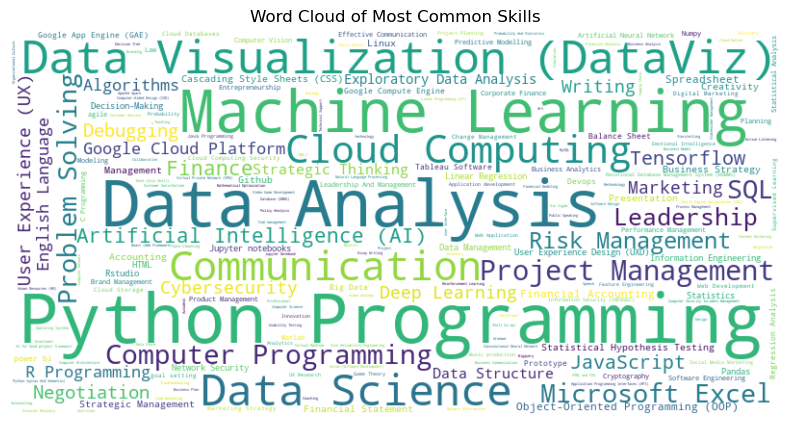

In [34]:
from wordcloud import WordCloud

# Generate a word cloud from the skill frequency data
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(skill_counts)

# Set up the figure size for the plot
plt.figure(figsize=(10, 5))

# Display the word cloud image with smooth rendering
plt.imshow(wordcloud, interpolation='bilinear')

# Remove axis labels and ticks
plt.axis('off')

# Set the title of the word cloud
plt.title("Word Cloud of Most Common Skills")

# Show the plot
plt.show()


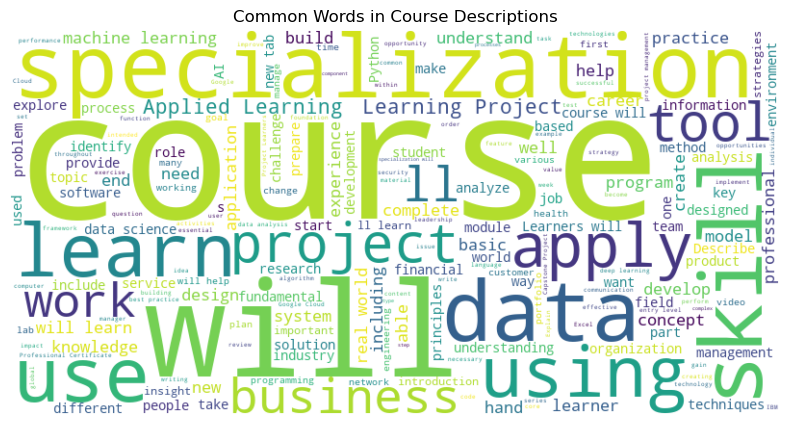

In [35]:
# Combine all non-null course descriptions into a single large text string
text = ' '.join(coursera_df['course_description'].dropna())

# Generate a word cloud from the combined text
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Set up the figure size for plotting
plt.figure(figsize=(10, 5))

# Display the word cloud with smooth rendering
plt.imshow(wordcloud, interpolation='bilinear')

# Hide the axes
plt.axis('off')

# Add a title to the plot
plt.title("Common Words in Course Descriptions")

# Show the word cloud plot
plt.show()


## LinkedIn Profiles EDA

In [37]:
people_df.head()

,Unnamed: 0,name,about,position,experience,education,courses,projects,experience_titles,recent_ed,experience_descriptions,course_titles,project_titles,project_desription,complete_profile,processed_profile,user_id
0,0,Sai S****s ***,Welcome to my LinkedIn profile! I am a motivat...,Associate Product Manager II @ShopDeck | Axxel...,"[{""company"":""ShopDeck"",""company_id"":""shopdeck""...","[{""degree"":""B.Tech"",""description"":""Activities ...",,,"Associate Product Manager II, Trainee Analyst,...",Mechanical Engineering,", » Executed numerous daily trading strategies...",,,,Welcome to my LinkedIn profile! I am a motivat...,welcom linkedin profil motiv result orient pro...,0
1,1,Lauren D****n,I lead inclusive programs to grow and develop ...,,,"[{""description"":null,""description_html"":null,""...","[{""subtitle"":""-"",""title"":""Applied Entrepreneur...","[{""description"":""Design and maintain website f...",,,,"Applied Entrepreneurship, Cost Control & Finan...",Promotion of Gateway Convention Center and Hot...,Design and maintain website for Gateway Conven...,I lead inclusive programs to grow and develop ...,lead inclus program grow develop peopl relatio...,1
2,2,Nishita G***a,- Leading Claims Analytics Team at Munich Re S...,Head of Large Loss & Claims Analytics - Global...,"[{""company"":""Munich Re"",""company_id"":""munich-r...","[{""degree"":""Master of Science - MS"",""descripti...","[{""subtitle"":""-"",""title"":""Big Data Seminar""},{...",,"Munich Re, MI Team Lead, Bristlecone",Business Intelligence and Analytics,", •\tLed MI & Analytics division by managing 4...","Big Data Seminar, Data Warehousing/Business In...",,,- Leading Claims Analytics Team at Munich Re S...,lead claim analyt team munich specialti insur ...,2
3,3,"John D******a M**, C***, C**, N**, R***, P**, **",Owner and President - AD Fiduciary - Fiduciary...,"Professional Fiduciary, Owner, President at AD...","[{""company"":""AD Fiduciary"",""company_logo_url"":...","[{""degree"":""MBA"",""description"":""Master of Busi...","[{""subtitle"":""-"",""title"":""RCFE Administrator C...",,"AD Fiduciary, IKOR International, President",Strategic Planning,", , Owner operator of residential care for the...",RCFE Administrator Certification,,,Owner and President - AD Fiduciary - Fiduciary...,owner presid ad fiduciari fiduciari servic mod...,3
4,4,Frederic L*****E,DIGITAL BUSINESS DESIGNER - I leverage digital...,,,"[{""description"":null,""description_html"":null,""...",,"[{""description"":""A Trusted Platform for Wirele...",,,,,European Union - T2R (Trusted Transaction Roam...,A Trusted Platform for Wireless Data Services ...,DIGITAL BUSINESS DESIGNER - I leverage digital...,digit busi design leverag digit assist individ...,4


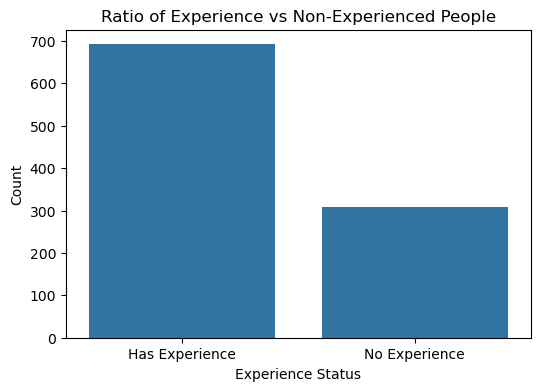

In [38]:
# Create a new Series indicating whether each person has any experience listed
# - If the 'experience_titles' field is non-empty after stripping whitespace, mark as 'Has Experience'
# - Otherwise, mark as 'No Experience'
experience_presence = people_df['experience_titles'].apply(lambda x: 'Has Experience' if x and x.strip() else 'No Experience')

# Set figure size for the plot
plt.figure(figsize=(6, 4))

# Plot the count of people with and without experience
sns.countplot(x=experience_presence)

# Set the title and axis labels
plt.title("Ratio of Experience vs Non-Experienced People")
plt.xlabel("Experience Status")
plt.ylabel("Count")

# Display the plot
plt.show()


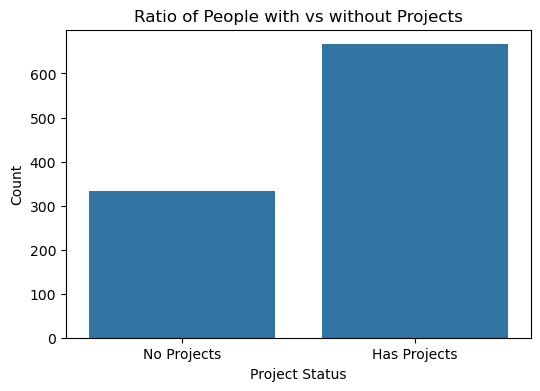

In [39]:
# Create a new Series to check whether each person has listed any projects
# - If 'project_titles' is non-empty after converting to string and stripping whitespace, mark as 'Has Projects'
# - Otherwise, mark as 'No Projects'
project_presence = people_df['project_titles'].apply(lambda x: 'Has Projects' if x and str(x).strip() else 'No Projects')

# Set the figure size for the plot
plt.figure(figsize=(6, 4))

# Plot the count of people with and without projects
sns.countplot(x=project_presence)

# Add a title and axis labels to the plot
plt.title("Ratio of People with vs without Projects")
plt.xlabel("Project Status")
plt.ylabel("Count")

# Display the plot
plt.show()


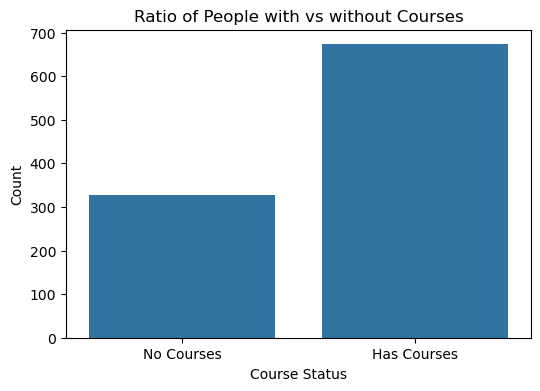

In [40]:
# Create a new Series to check whether each person has listed any courses
# - If 'course_titles' is non-empty after converting to string and stripping whitespace, mark as 'Has Courses'
# - Otherwise, mark as 'No Courses'
course_presence = people_df['course_titles'].apply(lambda x: 'Has Courses' if x and str(x).strip() else 'No Courses')

# Set the figure size for the plot
plt.figure(figsize=(6, 4))

# Plot the count of people with and without courses
sns.countplot(x=course_presence)

# Add a title and axis labels to the plot
plt.title("Ratio of People with vs without Courses")
plt.xlabel("Course Status")
plt.ylabel("Count")

# Display the plot
plt.show()

In [41]:
import ast

# Safely convert strings that look like lists into real Python lists
def safe_convert_skills(x):
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            return []
    return []

# Apply the fix
coursera_df['course_skills'] = coursera_df['course_skills'].apply(safe_convert_skills)

# TFIDF and Cosine Similarity

In [43]:
def data_preprocess(s_text):
    # Convert all text to lowercase
    s_text = s_text.str.lower()

    # Remove digits and non-word characters (e.g., punctuation, symbols)
    s_text = s_text.apply(lambda text: re.sub(r'[\d\W]+', ' ', str(text)))

    # Tokenize the text (split the text into individual words)
    s_text = s_text.apply(lambda text: word_tokenize(text))

    # Define the stopwords from the nltk library
    stop_words = set(stopwords.words('english'))

    # Add custom stopwords to the existing set
    custom_stopwords = {"course", "learning", "youll", "use", "courses", "skills", "using", "also", "new"}
    stop_words.update(custom_stopwords)

    # Remove stopwords from the tokenized words
    s_text = s_text.apply(lambda tokens: [word for word in tokens if word not in stop_words])

    # Apply stemming to reduce words to their base/root form
    stemmer = PorterStemmer()
    s_text = s_text.apply(lambda tokens: [stemmer.stem(word) for word in tokens])

    # Join the tokens back into a single string
    s_text = s_text.apply(lambda tokens: ' '.join(tokens))

    # Return the processed text
    return s_text


In [44]:
def make_DTM(col):
    # Select the specified column from the dataframe
    s_text = coursera_df[col]

    # Initialize a CountVectorizer for tokenizing and vectorizing the text data
    vectorizer = CountVectorizer()

    # Fit the vectorizer on the text and transform it into a Document-Term Matrix (DTM)
    X = vectorizer.fit_transform(s_text)

    # Convert the sparse matrix into a DataFrame with words as columns
    df_DTM = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
    
    # Sort the columns of the DTM based on word frequency (most frequent words first)
    word_occurrences = df_DTM.sum().sort_values(ascending=False)
    df_DTM_sorted = df_DTM[word_occurrences.index]
    
    #%% Count-Based Analysis
    # Calculate the total word count for each document (sum of terms in each row)
    total_word_count_per_doc = df_DTM.sum(axis=1)
    wc_tot = np.sort(total_word_count_per_doc)  # Sort the total word counts across documents
    
    # Calculate the word frequency across all documents (sum of terms in each column)
    word_frequency_across_docs = df_DTM.sum(axis=0)
    
    # Create a DataFrame showing each word's frequency across all documents
    word_frequency_table = pd.DataFrame(word_frequency_across_docs, columns=['Frequency']).reset_index()
    
    # Filter words that appear at least 'n' times across all documents
    n = 5  # You can adjust this threshold as needed
    words_at_least_n_times = word_frequency_table[word_frequency_table['Frequency'] >= n]
    
    # Define a list of words to be removed from the DTM
    words_to_remove = ['cours', 'learn', 'special', 'use']  # Add any additional stopwords here
    
    # Drop the specified words from the DTM
    filtered_df_DTM_sorted = df_DTM_sorted.drop(columns=words_to_remove, errors='ignore')
    
    #%% Re-run Count-Based Analysis on the filtered DTM
    # Calculate the total word count for each document (after removing selected words)
    total_wc = filtered_df_DTM_sorted.sum(axis=1)
    total_wc = total_wc.sort_values(ascending=False)  # Sort by word count
    
    # Calculate the word frequency across all documents (after removing selected words)
    word_freq = filtered_df_DTM_sorted.sum(axis=0).sort_values(ascending=False)
    
    # Return the filtered DTM and the word frequency across documents
    return filtered_df_DTM_sorted, word_freq


In [45]:
def tfidf_and_similarity(filtered_df_DTM_sorted):
    # Initialize the TfidfTransformer to convert word counts to TF-IDF scores
    tfidf = TfidfTransformer()

    # Apply the TF-IDF transformation to the filtered Document-Term Matrix (DTM)
    # 'filtered_df_DTM_sorted.values' converts the DTM DataFrame into a NumPy array
    X_tfidf = tfidf.fit_transform(filtered_df_DTM_sorted.values)

    # Convert the TF-IDF result into a DataFrame for easier inspection
    df_tfidf_sorted = pd.DataFrame(X_tfidf.toarray(), columns=filtered_df_DTM_sorted.columns)

    # If needed, you can check the TF-IDF values here, but it's not required in this function:
    X_tfidf.toarray()
    pca = PCA(n_components=500) 
    X_tfidf_reduced = pca.fit_transform(X_tfidf.toarray())

    # Compute cosine similarity between all documents based on their TF-IDF vectors
    similarity = cosine_similarity(X_tfidf_reduced, X_tfidf_reduced)

    # Return the cosine similarity matrix
    return similarity


In [46]:
def get_similar_courses(title, cosine_sim):
    # Create a Series with course titles as the index and their corresponding DataFrame index as values
    indices = pd.Series(coursera_df.index, index=coursera_df['course_title']).drop_duplicates()

    # Remove duplicated course titles by keeping only the last occurrence
    indices = indices[~indices.index.duplicated(keep='last')]

    # Find the index of the course title in the DataFrame
    course_index = indices[title]

    # Extract the cosine similarity scores for the course at 'course_index'
    cosine_sim[course_index]
    
    # Create a DataFrame of similarity scores for the selected course, with columns "score"
    similarity_scores = pd.DataFrame(cosine_sim[course_index], columns=["score"])

    # Sort the similarity scores in descending order and select the top 10 most similar courses (excluding itself)
    course_indices = similarity_scores.sort_values("score", ascending=False)[1:11].index

    # Return the course titles of the 10 most similar courses
    return coursera_df['course_title'].iloc[course_indices]


In [47]:
coursera_df['processed_description'] = data_preprocess(coursera_df['course_description'])

In [48]:
coursera_df['skills_str'] = coursera_df['course_skills'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)

In [49]:
coursera_df.head()

,course_title,course_organization,course_certificate_type,course_time,course_rating,course_difficulty,course_url,course_skills,course_description,course_id,processed_description,skills_str
0,(ISC)² Systems Security Certified Practitioner...,ISC2,Specialization,3 - 6 Months,4.7,Beginner,https://www.coursera.org/specializations/sscp-...,"[Risk Management, Access Control, Asset, Incid...",Pursue better IT security job opportunities an...,0,pursu better secur job opportun prove knowledg...,"Risk Management, Access Control, Asset, Incide..."
1,.NET FullStack Developer,Board Infinity,Specialization,1 - 3 Months,4.3,Intermediate,https://www.coursera.org/specializations/dot-n...,"[Web API, Web Development, Cascading Style She...",Develop the proficiency required to design and...,1,develop profici requir design develop comprehe...,"Web API, Web Development, Cascading Style Shee..."
2,21st Century Energy Transition: how do we make...,University of Alberta,Course,1 - 3 Months,4.8,Beginner,https://www.coursera.org/learn/21st-century-en...,[],"Affordable, abundant and reliable energy is fu...",2,afford abund reliabl energi fundament human we...,
3,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,Course,1 - 3 Months,4.7,Intermediate,https://www.coursera.org/learn/crash-course-in...,"[Instrumental Variable, Propensity Score Match...",We have all heard the phrase “correlation does...,3,heard phrase correl equal causat equal causat ...,"Instrumental Variable, Propensity Score Matchi..."
4,A life with ADHD,University of Geneva,Course,1 - 3 Months,NaN,Beginner,https://www.coursera.org/learn/life-with-adhd,"[differential diagnosis and comorbidities, sym...",What is ADHD and what are the challenges that ...,4,adhd challeng come whether person affect adhd ...,"differential diagnosis and comorbidities, symp..."


In [50]:
filtered_DTM_sorted_descp, word_freq_descp = make_DTM('processed_description')
filtered_DTM_sorted_skills, word_freq_skills = make_DTM('skills_str')

In [51]:
desc_similarity_matrix = tfidf_and_similarity(filtered_DTM_sorted_descp)
skills_similarity_matrix = tfidf_and_similarity(filtered_DTM_sorted_skills)

In [52]:
skills_similarity_matrix

array([[ 1.        , -0.02616281, -0.09255646, ..., -0.02963557,
        -0.02044079, -0.03554023],
       [-0.02616281,  1.        ,  0.00723095, ..., -0.01686904,
        -0.00785727, -0.01977208],
       [-0.09255646,  0.00723095,  1.        , ..., -0.00627566,
         0.05450437, -0.04184158],
       ...,
       [-0.02963557, -0.01686904, -0.00627566, ...,  1.        ,
         0.41111826,  0.59783795],
       [-0.02044079, -0.00785727,  0.05450437, ...,  0.41111826,
         1.        ,  0.40354157],
       [-0.03554023, -0.01977208, -0.04184158, ...,  0.59783795,
         0.40354157,  1.        ]])

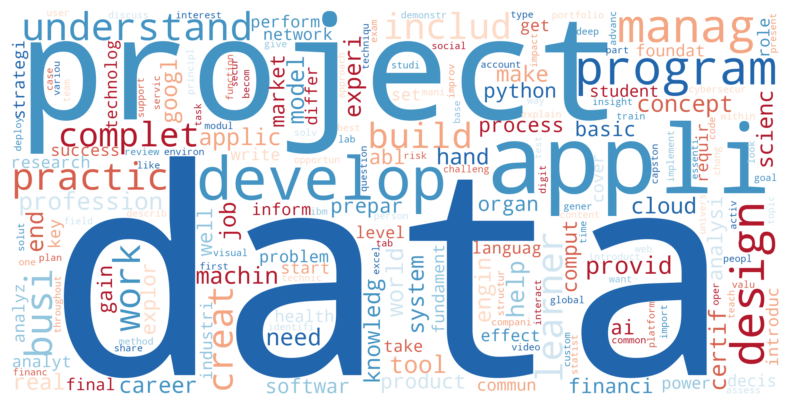

In [53]:
min_freq = 70
ind = word_freq_descp >= min_freq
word_freq_topN = word_freq_descp[ind]

wordcloud = WordCloud(width=800, height=400, scale=3, min_font_size=10,
            max_font_size=300, background_color='white',
            color_func=lambda *args, **kwargs: RdBu_8.hex_colors[np.random.randint(8)],
            random_state=False, prefer_horizontal=0.65).generate_from_frequencies(word_freq_topN)
# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

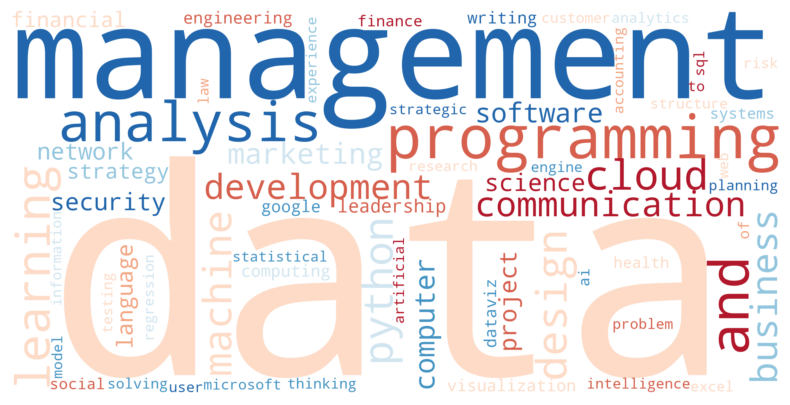

In [54]:
min_freq = 20
ind = word_freq_skills >= min_freq
word_freq_topN = word_freq_skills[ind]

wordcloud = WordCloud(width=800, height=400, scale=3, min_font_size=10,
            max_font_size=300, background_color='white',
            color_func=lambda *args, **kwargs: RdBu_8.hex_colors[np.random.randint(8)],
            random_state=False, prefer_horizontal=0.65).generate_from_frequencies(word_freq_topN)
# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

# Get Similar Courses

In [56]:
get_similar_courses('A Crash Course in Causality:  Inferring Causal Effects from Observational Data', skills_similarity_matrix)

224      Data Science Foundations: Statistical Inference
707            Methods and Statistics in Social Sciences
799                        Programming Languages, Part A
2      21st Century Energy Transition: how do we make...
147                                 Chemicals and Health
257                                       Digital Health
294     Entrepreneurship Strategy: From Ideation to Exit
12       AI Foundations: Prompt Engineering with ChatGPT
130                    Business and Marketing Strategies
301                   Ethics, Technology and Engineering
Name: course_title, dtype: object

In [57]:
get_similar_courses('A Crash Course in Causality:  Inferring Causal Effects from Observational Data', desc_similarity_matrix)

707            Methods and Statistics in Social Sciences
597              Introduction to Programming with MATLAB
776                                   Pre-MBA Statistics
218                         Data Engineering Foundations
95     Become a CBRS Certified Professional Installer...
899                               Statistics with Python
940                              The Power of Statistics
928    Terrorism and Counterterrorism: Comparing Theo...
613                       Introduction to Sustainability
649                             Learning and Development
Name: course_title, dtype: object

# Recommending Courses to LinkedIn profiles

In [59]:
vec = TfidfVectorizer(stop_words='english')

#Vectorize the course descriptions
course_vectors = vec.fit_transform(coursera_df['processed_description'])

In [60]:
def get_user_vector(user_id):
    user_text = people_df.loc[people_df['user_id'] == user_id, 'processed_profile'].values[0]
    # print(user_text)
    
    user_vector = vec.transform([user_text])
    return user_vector

In [61]:
def recommend_courses(user_id, top_n=5):
    # Get the user profile vector (could include experience, education, etc.)
    user_vector = get_user_vector(user_id)
    
    # Calculate cosine similarity between the user profile vector and all course vectors
    # Assuming `course_vectors` contains the precomputed vectors for the courses
    similarity_scores = cosine_similarity(user_vector, course_vectors).flatten()

    # (Optional) You can boost the similarity scores using a specific boost factor, if necessary
    # boosted_scores = boost_similarity_scores(similarity_scores, boost_factor)
    
    # Get the indices of the top N most similar courses
    top_indices = similarity_scores.argsort()[-top_n:][::-1]  # Sort the scores in descending order
    
    # Create a DataFrame of the top N recommended courses
    recommendations = coursera_df.iloc[top_indices].copy()
    
    # Add the similarity score for each recommended course to the DataFrame
    recommendations['similarity_score'] = similarity_scores[top_indices]

    # Get the person’s details from the people dataframe
    person = people_df.iloc[user_id]

    # Print personalized recommendations for the user
    print("Recommendations for ", person['name'], ": \n")
    print("Recent Experience: ", person['experience_titles'])
    print("Recent Education: ", person['recent_ed'])
    print(recommendations[['course_title', 'similarity_score']])  # Display recommended courses
    
    # Return the recommendations with course title, description, and similarity score
    return recommendations[['course_title', 'course_description', 'similarity_score']]


In [62]:
rec = recommend_courses(user_id=100, top_n=5)

Recommendations for  Omotolani K****u : 

Recent Experience:  Product Manager, Product Manager, Business Analyst
Recent Education:  Philosophy
                                          course_title  similarity_score
265  Digital Transformation Using AI/ML with Google...          0.470185
796           Product Ideation, Design, and Management          0.428315
596        Introduction to Probability and Data with R          0.393410
883                        Software Product Management          0.362959
264  Digital Technologies and the Future of Manufac...          0.335738


In [63]:
rec = recommend_courses(user_id=2, top_n=5)

Recommendations for  Nishita G***a : 

Recent Experience:  Munich Re, MI Team Lead, Bristlecone
Recent Education:  Business Intelligence and Analytics
                                      course_title  similarity_score
358  Foundations of Data Structures and Algorithms          0.414580
119     Business Data Management and Communication          0.377285
312      Excel Skills for Business: Intermediate I          0.373225
558               Introduction to Data Engineering          0.371487
718                Microsoft Power BI Data Analyst          0.369172


In [65]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')  # A fast and lightweight model

C:\Users\dell\anaconda3\lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [66]:
course_embeddings = model.encode(coursera_df['processed_description'].fillna("").tolist(), show_progress_bar=True)

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [67]:
user_embeddings = model.encode(people_df['processed_profile'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [68]:
similarity_matrix = cosine_similarity(user_embeddings, course_embeddings)

In [69]:
def recommend_courses_for_user_bert(user_id, similarity_matrix, top_n=5):
    if user_id >= similarity_matrix.shape[0]:
        raise ValueError("User ID exceeds number of users in similarity matrix.")
    
    user_similarities = similarity_matrix[user_id]
    top_indices = np.argsort(-user_similarities)[:top_n]

    recommendations = coursera_df.iloc[top_indices].copy()
    
    # Add the similarity score for each recommended course to the DataFrame
    recommendations['similarity_score'] = user_similarities[top_indices]
    
    person = people_df.iloc[user_id]

    # Print personalized recommendations for the user
    print("Recommendations for ", person['name'], ": \n")
    print("Recent Experience: ", person['experience_titles'])
    print("Recent Education: ", person['recent_ed'])
    print(recommendations[['course_title', 'similarity_score']])  # Display recommended courses
    
    return recommendations[['course_title', 'course_description', 'similarity_score']]


In [70]:
rec = recommend_courses_for_user_bert(100, similarity_matrix, top_n=5)

Recommendations for  Omotolani K****u : 

Recent Experience:  Product Manager, Product Manager, Business Analyst
Recent Education:  Philosophy
                                          course_title  similarity_score
796           Product Ideation, Design, and Management          0.631785
264  Digital Technologies and the Future of Manufac...          0.621508
967                User Experience Research and Design          0.574939
682                       Marketing Mix Implementation          0.573899
883                        Software Product Management          0.567607
